# KMeans Clustering on ECG200

This notebook loads ECG200 time-series data from UCR, applies KMeans clustering, and compares discovered clusters to known class labels.

In [9]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mitigates common MKL warning for KMeans on Windows
os.environ.setdefault('OMP_NUM_THREADS', '1')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
    accuracy_score,
    normalized_mutual_info_score,
    )
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

In [10]:
# Resolve UCR root for common local layouts
root_candidates = [
    (Path('..') / '..' / 'data' / 'UCRArchive_2018').resolve(),
    (Path('..') / '..' / 'data' / 'UCRArchive_2018' / 'UCRArchive_2018').resolve(),
]
UCR_ROOT = next((p for p in root_candidates if p.exists()), root_candidates[0])

dataset_name = 'ECG200'
train_path = UCR_ROOT / dataset_name / f'{dataset_name}_TRAIN.tsv'
test_path = UCR_ROOT / dataset_name / f'{dataset_name}_TEST.tsv'

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        f'Could not find ECG200 files. Checked: {train_path} and {test_path}'
    )

train_df = pd.read_csv(train_path, sep='\t', header=None)
test_df = pd.read_csv(test_path, sep='\t', header=None)
df = pd.concat([train_df, test_df], ignore_index=True)

y_true = df.iloc[:, 0].to_numpy()
X = df.iloc[:, 1:].to_numpy()

print('UCR root:', UCR_ROOT)
print('Dataset:', dataset_name)
print('Samples x Features:', X.shape)
print('Classes:', np.unique(y_true))

UCR root: D:\repositories\personal\xai-spatio-temporal\data\UCRArchive_2018
Dataset: ECG200
Samples x Features: (200, 96)
Classes: [-1  1]


Per-series mean (avg +/- std): 0.0 +/- 0.0
Per-series std  (avg +/- std): 0.9948 +/- 0.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_23228\3424143111.py:23: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances.append(np.abs(np.cross(line, p - p1)) / line_norm)


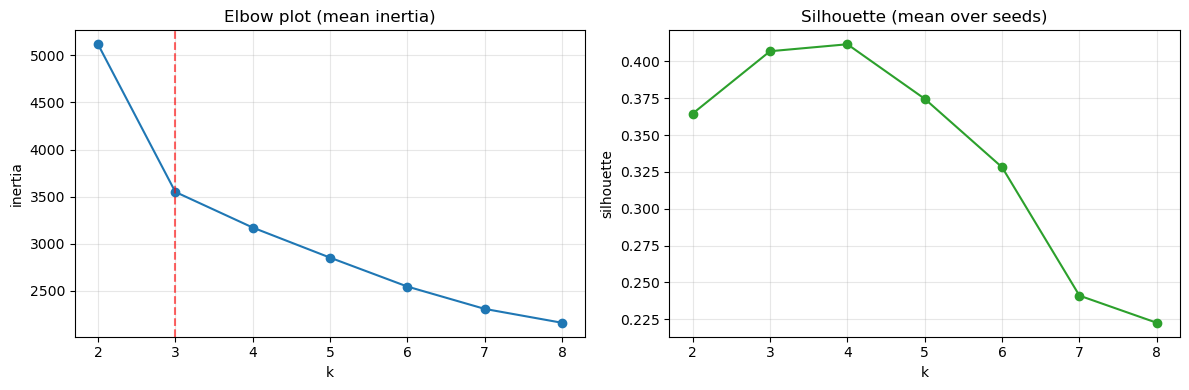

,k,silhouette,silhouette_std,calinski_harabasz,davies_bouldin,stability_ari,stability_ari_std,elbow_k,rank_sum,rank_sum_penalized
0,3,0.406866,0.000078,114.966840,1.091254,0.987186,0.015694,3,7.5,7.65
1,4,0.411593,0.002075,93.123024,1.026761,0.974119,0.017584,3,8.0,8.30
2,2,0.364550,0.000000,99.681045,1.104280,1.000000,0.000000,3,11.0,11.00
3,5,0.374555,0.021043,82.720168,1.090755,0.902587,0.083983,3,15.0,15.45
4,6,0.328106,0.003305,78.455021,1.210253,0.971985,0.022027,3,19.0,19.60
5,7,0.240987,0.002091,75.026760,1.340703,0.953860,0.038655,3,23.0,23.75
6,8,0.222550,0.011298,70.206768,1.347883,0.788191,0.079977,3,28.0,28.90


Best k (unsupervised, no labels used): 3


In [3]:
# Check whether each time series already looks z-normalized
row_means = X.mean(axis=1)
row_stds = X.std(axis=1, ddof=0)
print('Per-series mean (avg +/- std):', round(float(row_means.mean()), 4), '+/-', round(float(row_means.std()), 4))
print('Per-series std  (avg +/- std):', round(float(row_stds.mean()), 4), '+/-', round(float(row_stds.std()), 4))

# Use raw data for unsupervised k selection
k_values = list(range(2, 9))
seed_list = [0, 1, 2, 3, 4]

def elbow_k_from_line(k_list, inertia_list):
    x = np.asarray(k_list, dtype=float)
    y = np.asarray(inertia_list, dtype=float)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    line = p2 - p1
    line_norm = np.linalg.norm(line)
    if line_norm == 0:
        return int(k_list[0])
    distances = []
    for i in range(len(x)):
        p = np.array([x[i], y[i]])
        distances.append(np.abs(np.cross(line, p - p1)) / line_norm)
    return int(k_list[int(np.argmax(distances))])

rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

inertias = []
silhouettes = []
silhouettes_std = []
ch_scores = []
ch_scores_std = []
db_scores = []
db_scores_std = []
stabilities = []
stabilities_std = []

for k in k_values:
    labels_by_seed = []
    inertias_by_seed = []
    sil_by_seed = []
    ch_by_seed = []
    db_by_seed = []

    for seed in seed_list:
        km = KMeans(n_clusters=k, random_state=seed, n_init=20)
        labels = km.fit_predict(X)
        labels_by_seed.append(labels)
        inertias_by_seed.append(float(km.inertia_))
        sil_by_seed.append(float(silhouette_score(X, labels)))
        ch_by_seed.append(float(calinski_harabasz_score(X, labels)))
        db_by_seed.append(float(davies_bouldin_score(X, labels)))

    inertias.append(float(np.mean(inertias_by_seed)))
    silhouettes.append(float(np.mean(sil_by_seed)))
    silhouettes_std.append(float(np.std(sil_by_seed, ddof=0)))
    ch_scores.append(float(np.mean(ch_by_seed)))
    ch_scores_std.append(float(np.std(ch_by_seed, ddof=0)))
    db_scores.append(float(np.mean(db_by_seed)))
    db_scores_std.append(float(np.std(db_by_seed, ddof=0)))

    pairwise_ari = []
    for i in range(len(labels_by_seed)):
        for j in range(i + 1, len(labels_by_seed)):
            pairwise_ari.append(adjusted_rand_score(labels_by_seed[i], labels_by_seed[j]))
    stabilities.append(float(np.mean(pairwise_ari)))
    stabilities_std.append(float(np.std(pairwise_ari, ddof=0)))

elbow_k = elbow_k_from_line(k_values, inertias)

for i, k in enumerate(k_values):
    rows.append({
        'k': k,
        'inertia': inertias[i],
        'silhouette': silhouettes[i],
        'silhouette_std': silhouettes_std[i],
        'calinski_harabasz': ch_scores[i],
        'calinski_harabasz_std': ch_scores_std[i],
        'davies_bouldin': db_scores[i],
        'davies_bouldin_std': db_scores_std[i],
        'stability_ari': stabilities[i],
        'stability_ari_std': stabilities_std[i],
        'elbow_k': elbow_k,
        'elbow_match': int(k == elbow_k),
    })

axes[0].plot(k_values, inertias, marker='o')
axes[0].axvline(elbow_k, color='r', linestyle='--', alpha=0.6)
axes[0].set_title('Elbow plot (mean inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_values, silhouettes, marker='o', color='tab:green')
axes[1].set_title('Silhouette (mean over seeds)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

selection_df = pd.DataFrame(rows)

for metric in ['silhouette', 'calinski_harabasz', 'stability_ari']:
    selection_df[f'rank_{metric}'] = selection_df[metric].rank(method='dense', ascending=False)
selection_df['rank_davies_bouldin'] = selection_df['davies_bouldin'].rank(method='dense', ascending=True)

selection_df['rank_sum'] = (
    selection_df['rank_silhouette']
    + selection_df['rank_calinski_harabasz']
    + selection_df['rank_davies_bouldin']
    + selection_df['rank_stability_ari']
    - 0.5 * selection_df['elbow_match']
    )

# Mild simplicity bias: prefer smaller k when unsupervised scores are close (no labels used)
min_k = min(k_values)
k_penalty = 0.15
selection_df['rank_sum_penalized'] = selection_df['rank_sum'] + k_penalty * (selection_df['k'] - min_k)

selection_df = selection_df.sort_values(
    ['rank_sum_penalized', 'silhouette', 'stability_ari', 'k'],
    ascending=[True, False, False, True],
).reset_index(drop=True)

display(selection_df[[
    'k',
    'silhouette',
    'silhouette_std',
    'calinski_harabasz',
    'davies_bouldin',
    'stability_ari',
    'stability_ari_std',
    'elbow_k',
    'rank_sum',
    'rank_sum_penalized',
]])

best_k = int(selection_df.iloc[0]['k'])

print('Best k (unsupervised, no labels used):', best_k)

In [4]:
# Post-hoc label benchmark (uses y_true only for evaluation) at selected k
def majority_label_mapping(y_ref, clusters):
    mapping = {}
    for c in np.unique(clusters):
        mapping[c] = pd.Series(y_ref[clusters == c]).mode().iloc[0]
    return mapping

def mapped_predictions(clusters, mapping):
    return np.array([mapping[c] for c in clusters])

km_eval = KMeans(n_clusters=best_k, random_state=42, n_init=50)
cl_eval = km_eval.fit_predict(X)
map_eval = majority_label_mapping(y_true, cl_eval)
pred_eval = mapped_predictions(cl_eval, map_eval)

benchmark_data = {
    'k': int(best_k),
    'mapped_accuracy': float(accuracy_score(y_true, pred_eval)),
    'ari': float(adjusted_rand_score(y_true, cl_eval)),
    'nmi': float(normalized_mutual_info_score(y_true, cl_eval)),
    'silhouette': float(silhouette_score(X, cl_eval)),
    'clusters': int(len(np.unique(cl_eval))),
    'classes': int(len(np.unique(y_true))),
}

benchmark_df = pd.DataFrame([benchmark_data])

display(benchmark_df)

print('Note: the table above uses ground-truth labels for evaluation only (not for selecting k).')
print('Unsupervised k selection:', {'k': best_k})

,k,mapped_accuracy,ari,nmi,silhouette,clusters,classes
0,3,0.78,0.312028,0.203882,0.406905,3,2


Note: the table above uses ground-truth labels for evaluation only (not for selecting k).
Unsupervised k selection: {'k': 3}


In [5]:
# Fit KMeans using best_k on raw data
model = KMeans(n_clusters=best_k, random_state=42, n_init=50)
labels = model.fit_predict(X)

summary_data = {
    'k': int(best_k),
    'inertia': float(model.inertia_),
    'silhouette': float(silhouette_score(X, labels)),
    'calinski_harabasz': float(calinski_harabasz_score(X, labels)),
    'davies_bouldin': float(davies_bouldin_score(X, labels)),
}

fit_summary_df = pd.DataFrame([summary_data])
display(fit_summary_df)

print('Final model: k=%d' % best_k)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,3,3549.835087,0.406905,114.971914,1.089663


Final model: k=3


In [6]:
# Compare clusters vs labels
comparison = pd.DataFrame({'true_label': y_true, 'cluster': labels})
crosstab = pd.crosstab(comparison['true_label'], comparison['cluster'])

print('Cluster-Label Crosstab:')
display(crosstab)

majority_mapping = {}
for c in sorted(comparison['cluster'].unique()):
    mode_label = comparison.loc[comparison['cluster'] == c, 'true_label'].mode().iloc[0]
    majority_mapping[c] = mode_label

predicted_by_cluster = np.array([majority_mapping[c] for c in comparison['cluster']])
agreement = (predicted_by_cluster == y_true).mean()
ari_score = adjusted_rand_score(y_true, labels)
nmi_score = normalized_mutual_info_score(y_true, labels)

print('\nCluster -> label mapping:', majority_mapping)
print('Agreement with true labels (majority-mapped):', round(float(agreement), 4))
print('Adjusted Rand Index:', round(float(ari_score), 4))
print('Normalized Mutual Information:', round(float(nmi_score), 4))

Cluster-Label Crosstab:


cluster,0,1,2
true_label,,,
-1,11,35,21
1,100,19,14



Cluster -> label mapping: {np.int32(0): np.int64(1), np.int32(1): np.int64(-1), np.int32(2): np.int64(-1)}
Agreement with true labels (majority-mapped): 0.78
Adjusted Rand Index: 0.312
Normalized Mutual Information: 0.2039


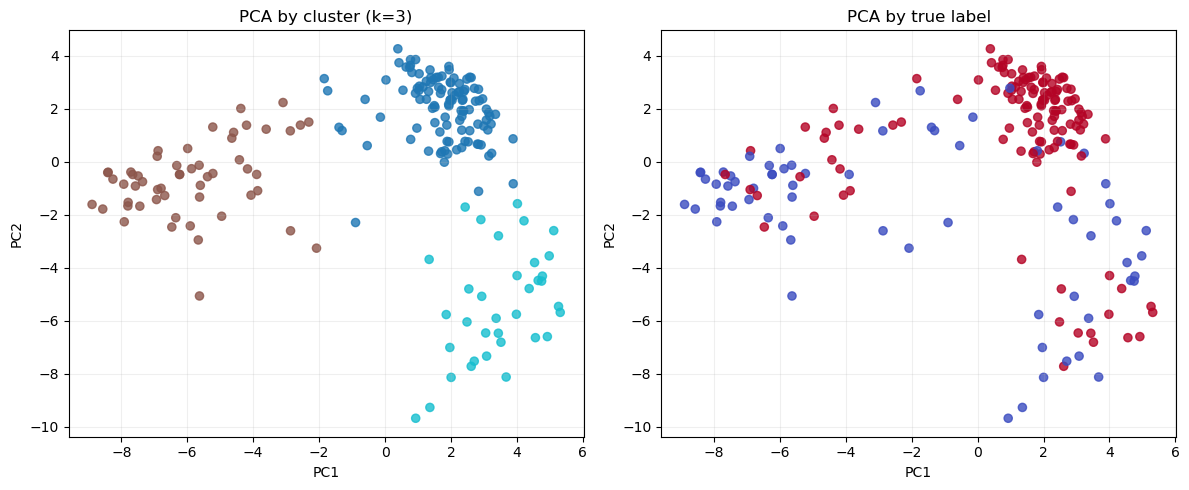

In [7]:
# 2D projection for visual inspection
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=35, cmap='tab10', alpha=0.8)
axes[0].set_title('PCA by cluster (k=%d)' % best_k)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.2)

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, s=35, cmap='coolwarm', alpha=0.8)
axes[1].set_title('PCA by true label')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Surrogate tree train fidelity: 0.985
Surrogate tree CV fidelity: 0.94

Surrogate rules:

|--- t_41 <= -0.60
|   |--- class: 1
|--- t_41 >  -0.60
|   |--- t_30 <= -1.45
|   |   |--- t_12 <= -0.76
|   |   |   |--- class: 0
|   |   |--- t_12 >  -0.76
|   |   |   |--- class: 0
|   |--- t_30 >  -1.45
|   |   |--- t_30 <= -0.70
|   |   |   |--- class: 2
|   |   |--- t_30 >  -0.70
|   |   |   |--- class: 2



,feature,importance
41,t_41,0.570841
30,t_30,0.427106
12,t_12,0.002053
2,t_2,0.000000
4,t_4,0.000000
5,t_5,0.000000
6,t_6,0.000000
0,t_0,0.000000
7,t_7,0.000000
8,t_8,0.000000


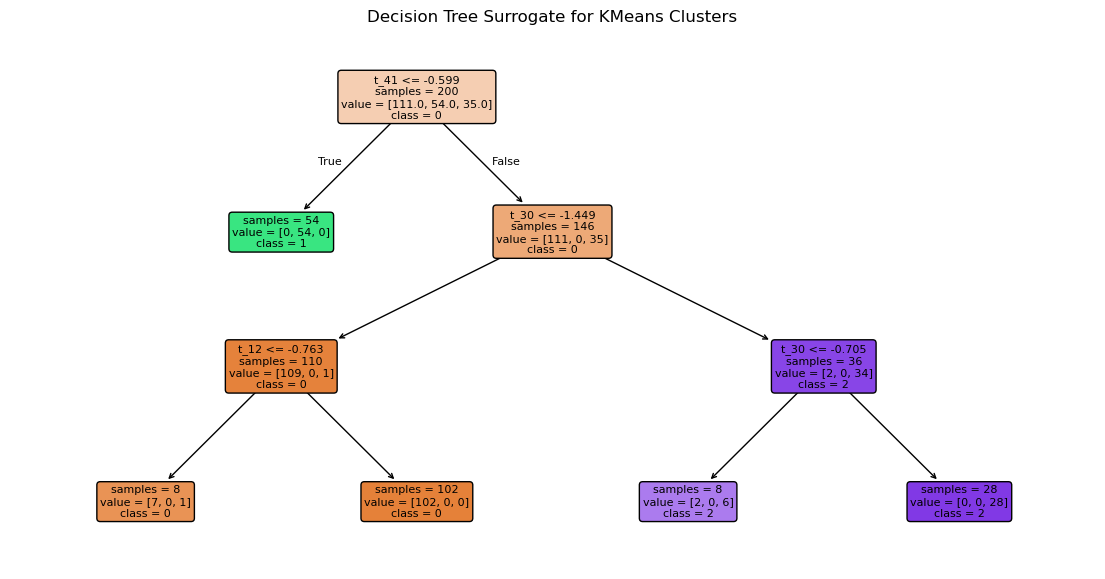

In [8]:
# Train surrogate decision tree for explainability
feature_names = [f't_{i}' for i in range(X.shape[1])]

surrogate = DecisionTreeClassifier(max_depth=3, min_samples_leaf=8, random_state=42)
surrogate.fit(X, labels)

surrogate_pred = surrogate.predict(X)
train_fidelity = accuracy_score(labels, surrogate_pred)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_fidelity = cross_val_score(
    surrogate, X, labels, cv=cv, scoring='accuracy'
).mean()

print('Surrogate tree train fidelity:', round(float(train_fidelity), 4))
print('Surrogate tree CV fidelity:', round(float(cv_fidelity), 4))

rules = export_text(surrogate, feature_names=feature_names)
print('\nSurrogate rules:\n')
print(rules)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': surrogate.feature_importances_,
}).sort_values('importance', ascending=False)

display(importance_df.head(10))

plt.figure(figsize=(14, 7))
plot_tree(
    surrogate,
    feature_names=feature_names,
    class_names=[str(c) for c in sorted(np.unique(labels))],
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=8,
)
plt.title('Decision Tree Surrogate for KMeans Clusters')
plt.show()

In [ ]:
# SHAP feature attributions for surrogate tree
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print('SHAP is not installed. Install with: pip install shap')

if shap_available:
    explainer = shap.TreeExplainer(surrogate)
    raw_shap = explainer.shap_values(X)

    # Aggregate class-wise outputs for multiclass trees
    if isinstance(raw_shap, list):
        shap_abs_mean = np.mean(
            np.stack([np.abs(class_values).mean(axis=0) for class_values in raw_shap], axis=0),
            axis=0,
        )
        shap_for_beeswarm = raw_shap[0]
    elif isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
        shap_abs_mean = np.abs(raw_shap).mean(axis=(0, 2))
        shap_for_beeswarm = raw_shap[:, :, 0]
    else:
        shap_abs_mean = np.abs(raw_shap).mean(axis=0)
        shap_for_beeswarm = raw_shap

    shap_importance_df = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': shap_abs_mean,
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    print('Top SHAP features:')
    display(shap_importance_df.head(15))

    top_n = 15
    top_df = shap_importance_df.head(top_n).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(top_df['feature'], top_df['mean_abs_shap'])
    plt.title('Top SHAP Features for KMeans Surrogate')
    plt.xlabel('Mean(|SHAP value|)')
    plt.tight_layout()
    plt.show()

    # SHAP beeswarm plot
    try:
        shap.summary_plot(
            shap_for_beeswarm,
            pd.DataFrame(X, columns=feature_names),
            max_display=15,
            show=True,
        )
    except Exception as ex:
        print('Could not render SHAP beeswarm summary:', ex)

## SHAP explanation of KMeans surrogate

The SHAP values below explain the surrogate decision tree that approximates KMeans assignments. This gives feature-level attribution for why a sample is routed to a particular cluster region.

## Why KMeans can be explainable

KMeans is prototype-based: each cluster has a centroid, and each sample is assigned to the nearest centroid in Euclidean distance. This is interpretable through centroid shapes and distance-to-centroid logic.

A practical way to explain assignments is to train a shallow surrogate model (for example, a decision tree) to predict KMeans cluster labels from the same features. High surrogate fidelity means the tree captures most of KMeans behavior in readable rules.

In [ ]:
feature_idx = 41
print("Raw dataframe columns shown: [label, t_41]")
display(df.iloc[:10, [0, 1 + feature_idx]])

print("Same values as numpy X[:, 41] (first 10):")
print(X[:10, feature_idx])

print("Range/quantiles of t_41 (raw data):")
vals = X[:, feature_idx]
print(np.quantile(vals, [0, 0.01, 0.05, 0.5, 0.95, 0.99, 1.0]))

Raw dataframe columns shown: [label, t_41]


,0,42
0,-1,-1.423810
1,1,0.750518
2,-1,-1.509483
3,-1,-1.729149
4,1,0.700880
5,1,0.194320
6,-1,-1.735507
7,-1,-0.706255
8,1,0.606465
9,1,0.655109


Same values as numpy X[:, 41] (first 10):
[-1.4238097   0.75051788 -1.5094832  -1.7291486   0.70087985  0.19431966
 -1.7355071  -0.70625453  0.60646546  0.65510886]
Range/quantiles of t_41 (raw view):
[-1.9967517  -1.89403023 -1.74000543  0.49020393  0.95396227  1.10667391
  1.3428101 ]


## Abductive explanations for raw time-series clustering

This section computes abductive edits from surrogate rules for the raw-data KMeans pipeline. For each sampled point, it reports a minimal rule-consistent feature edit that flips the surrogate cluster prediction.

In [ ]:
def _leaf_constraints(tree_):
    n_features = tree_.n_features
    constraints = {}

    def walk(node_id, low, high):
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]

        if left_id == right_id:
            constraints[node_id] = (low.copy(), high.copy())
            return

        feat = tree_.feature[node_id]
        thr = tree_.threshold[node_id]

        high_left = high.copy()
        high_left[feat] = min(high_left[feat], thr)
        walk(left_id, low.copy(), high_left)

        low_right = low.copy()
        low_right[feat] = max(low_right[feat], np.nextafter(thr, np.inf))
        walk(right_id, low_right, high.copy())

    walk(
        0,
        np.full(n_features, -np.inf, dtype=float),
        np.full(n_features, np.inf, dtype=float),
    )
    return constraints


def _as_scalar_label(value):
    try:
        return int(value)
    except Exception:
        return value


def _best_abductive_edit(surrogate, x_row, feature_names, max_display_features=6):
    tree_ = surrogate.tree_
    leaf_rules = _leaf_constraints(tree_)
    classes = surrogate.classes_

    current_label = surrogate.predict(x_row.reshape(1, -1))[0]
    current_label_scalar = _as_scalar_label(current_label)

    best = None
    for leaf_id, (low, high) in leaf_rules.items():
        target_idx = int(np.argmax(tree_.value[leaf_id][0]))
        target_label = classes[target_idx]
        target_label_scalar = _as_scalar_label(target_label)

        if target_label_scalar == current_label_scalar:
            continue

        x_new = x_row.astype(float).copy()
        edits = []
        for feat_idx in range(x_new.shape[0]):
            old_val = float(x_new[feat_idx])
            new_val = old_val

            if old_val < low[feat_idx]:
                new_val = float(low[feat_idx])
            elif old_val > high[feat_idx]:
                new_val = float(high[feat_idx])

            if new_val != old_val:
                x_new[feat_idx] = new_val
                edits.append((feat_idx, old_val, new_val, abs(new_val - old_val)))

        predicted_new = surrogate.predict(x_new.reshape(1, -1))[0]
        predicted_new_scalar = _as_scalar_label(predicted_new)
        if predicted_new_scalar != target_label_scalar:
            continue

        n_changed = len(edits)
        total_shift = float(sum(item[3] for item in edits))

        changed_features = [feature_names[item[0]] for item in edits]
        edits_preview = '; '.join(
            [
                f"{feature_names[item[0]]}: {item[1]:.3f} -> {item[2]:.3f}"
                for item in edits[:max_display_features]
            ]
        )

        candidate = {
            'original_cluster': current_label_scalar,
            'target_cluster': target_label_scalar,
            'n_features_changed': n_changed,
            'total_abs_shift': total_shift,
            'changed_features': ', '.join(changed_features),
            'suggested_edits': edits_preview,
        }

        if best is None:
            best = candidate
        else:
            current_score = (candidate['n_features_changed'], candidate['total_abs_shift'])
            best_score = (best['n_features_changed'], best['total_abs_shift'])
            if current_score < best_score:
                best = candidate

    return best


sample_count = min(12, X.shape[0])
sample_indices = np.unique(np.linspace(0, X.shape[0] - 1, num=sample_count, dtype=int))

rows = []
for idx in sample_indices:
    best_edit = _best_abductive_edit(surrogate, X[idx], feature_names)
    if best_edit is None:
        continue
    rows.append({'sample_idx': int(idx), **best_edit})

abductive_df = pd.DataFrame(rows)
print('Raw-data abductive explanations from surrogate rules')
if abductive_df.empty:
    print('No abductive edits found for the sampled points.')
else:
    display(abductive_df.head(12))
    summary = abductive_df[['n_features_changed', 'total_abs_shift']].agg(['mean', 'min', 'max'])
    print('Abductive summary stats:')
    display(summary)